In [1]:
import sys
sys.path.insert(0, '..')   # lets notebook find the regimesense package

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from regimesense.data.fetcher import load_data_from_config
from regimesense.features.regime_features import build_feature_matrix, normalize_features

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11

print("Imports OK")

Imports OK


In [2]:
df       = load_data_from_config()
features = build_feature_matrix(df)
normed   = normalize_features(features)

print(f"Price data:    {df.shape[0]} days, {df.index[0].date()} → {df.index[-1].date()}")
print(f"Feature matrix: {features.shape[0]} rows × {features.shape[1]} features")
print()
print(features.describe().round(3))

2026-03-18 19:31:42,857  INFO  Fetching SPY from 2010-01-01 to 2024-12-31 ...
2026-03-18 19:31:43,438  INFO  Fetched 3773 trading days for SPY.
2026-03-18 19:31:43,440  INFO  Computing regime features ...
2026-03-18 19:31:45,270  INFO  Feature matrix: 3713 rows (60 dropped for rolling warm-up).


Price data:    3773 days, 2010-01-04 → 2024-12-30
Feature matrix: 3713 rows × 5 features

       realized_vol  autocorr_5d  rolling_sharpe  skewness  volume_momentum
count      3713.000     3713.000        3713.000  3713.000         3713.000
mean          0.146       -0.050           1.350    -0.325            1.001
std           0.091        0.155           1.800     0.572            0.206
min           0.032       -0.532          -4.094    -3.152            0.502
25%           0.091       -0.158           0.116    -0.689            0.866
50%           0.122       -0.054           1.354    -0.294            0.975
75%           0.174        0.052           2.554     0.035            1.102
max           0.939        0.447           7.475     1.398            2.251


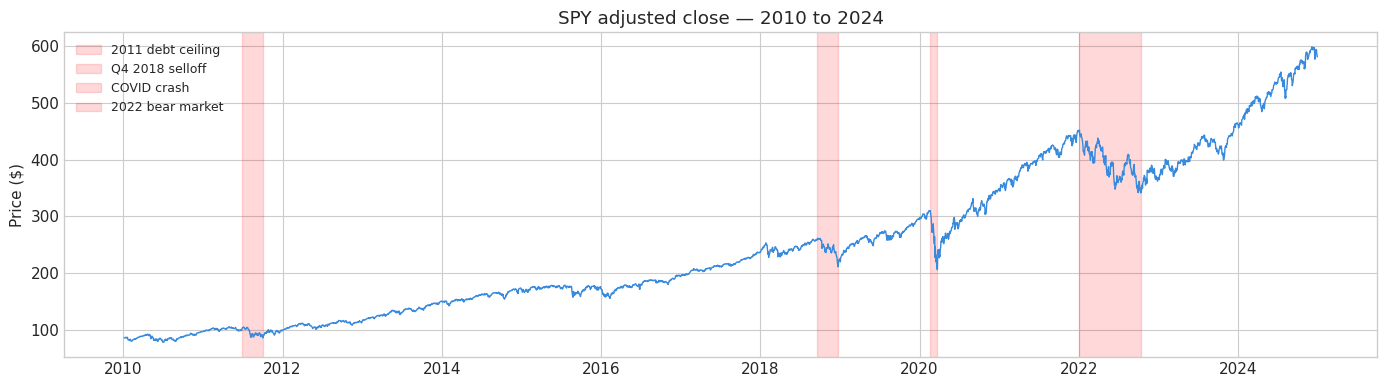

In [3]:
fig, ax = plt.subplots()
ax.plot(df.index, df['Close'], linewidth=1, color='#378ADD')
ax.set_title("SPY adjusted close — 2010 to 2024")
ax.set_ylabel("Price ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Shade known crisis periods so you can see them visually
crises = [("2011-07-01", "2011-10-03", "2011 debt ceiling"),
          ("2018-09-20", "2018-12-24", "Q4 2018 selloff"),
          ("2020-02-19", "2020-03-23", "COVID crash"),
          ("2022-01-03", "2022-10-12", "2022 bear market")]

for start, end, label in crises:
    ax.axvspan(start, end, alpha=0.15, color='red', label=label)

ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

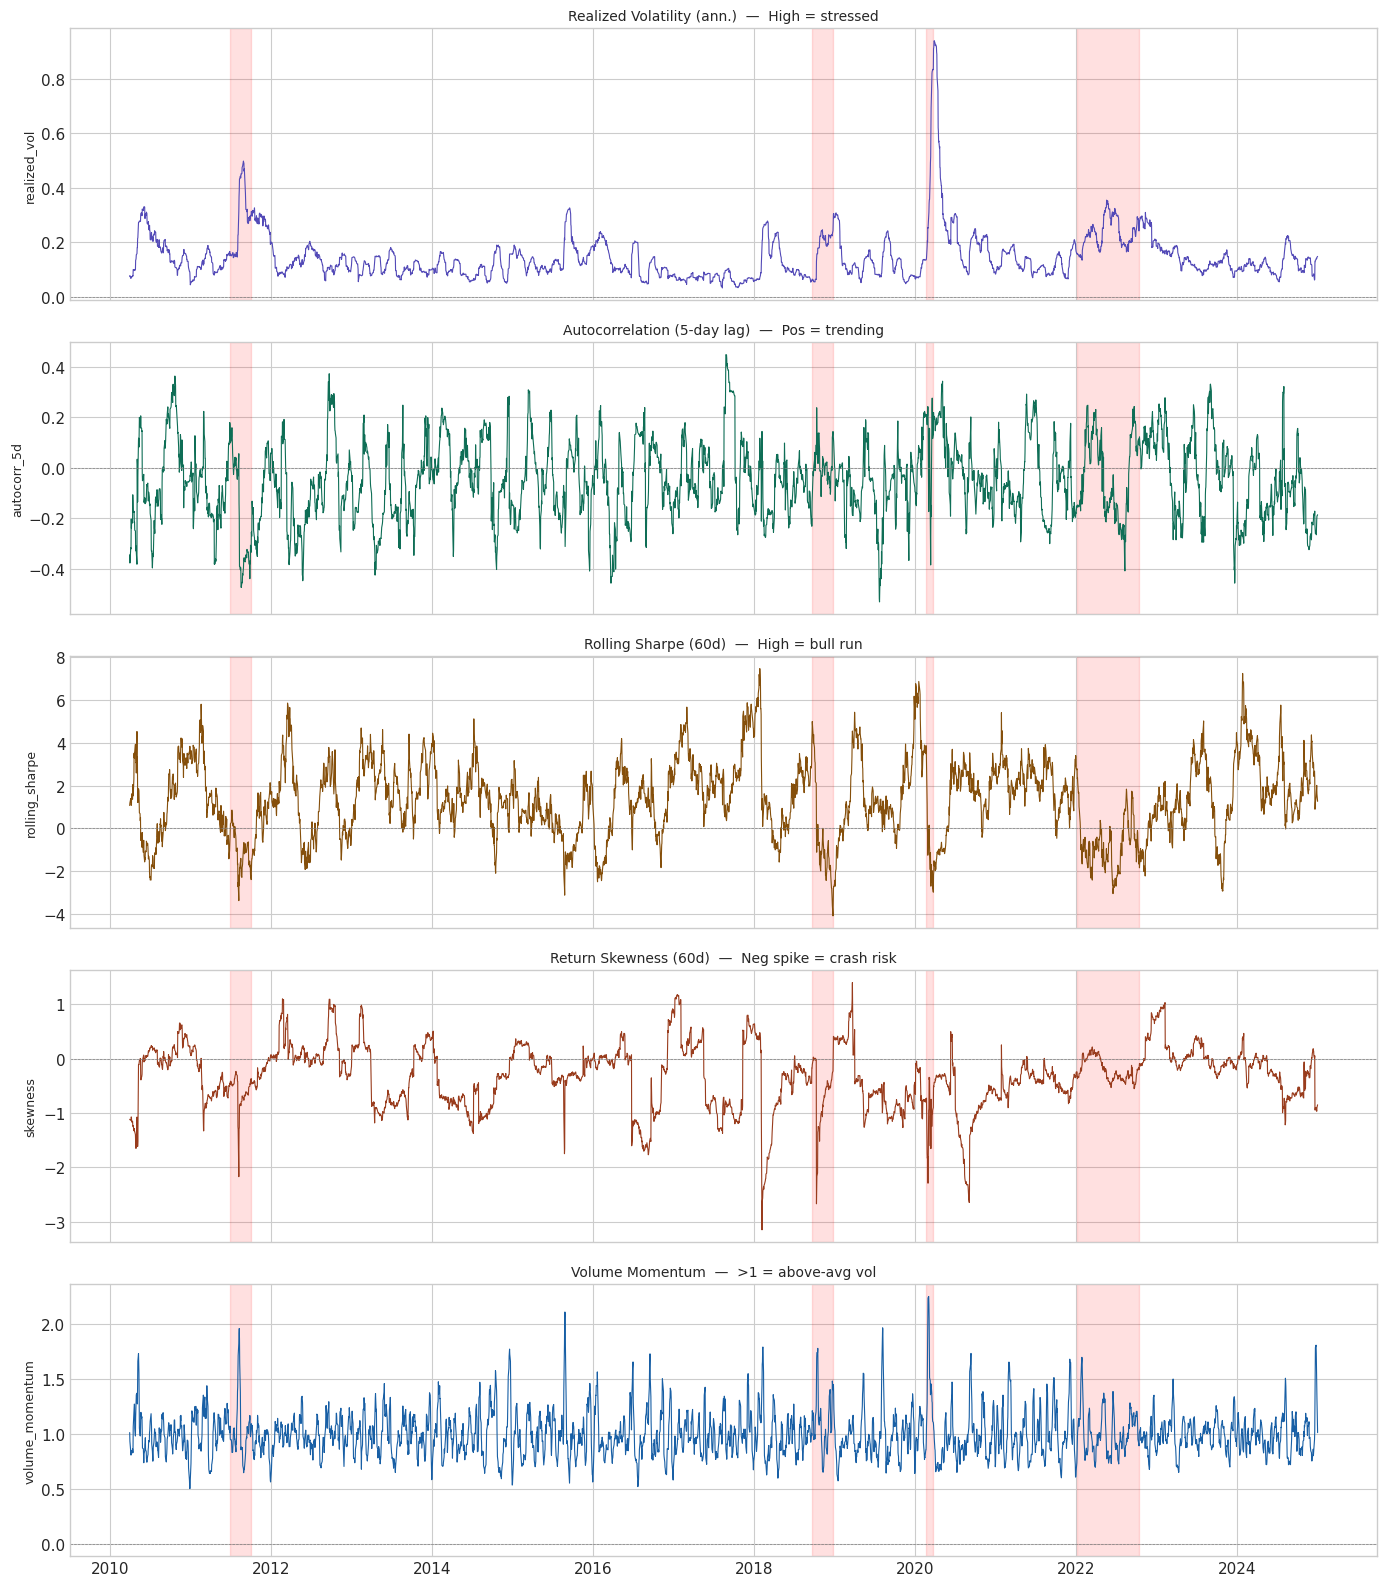

Saved to logs/feature_overview.png


In [5]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

feature_meta = [
    ("realized_vol",    "Realized Volatility (ann.)",   "#534AB7", "High = stressed"),
    ("autocorr_5d",     "Autocorrelation (5-day lag)",  "#0F6E56", "Pos = trending"),
    ("rolling_sharpe",  "Rolling Sharpe (60d)",         "#854F0B", "High = bull run"),
    ("skewness",        "Return Skewness (60d)",        "#993C1D", "Neg spike = crash risk"),
    ("volume_momentum", "Volume Momentum",              "#185FA5", ">1 = above-avg vol"),
]

for ax, (col, title, color, note) in zip(axes, feature_meta):
    ax.plot(features.index, features[col], linewidth=0.8, color=color)
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(f"{title}  —  {note}", fontsize=10)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

    # Shade crises so you can see how features react
    for start, end, _ in crises:
        ax.axvspan(start, end, alpha=0.12, color='red')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('../logs/feature_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to logs/feature_overview.png")

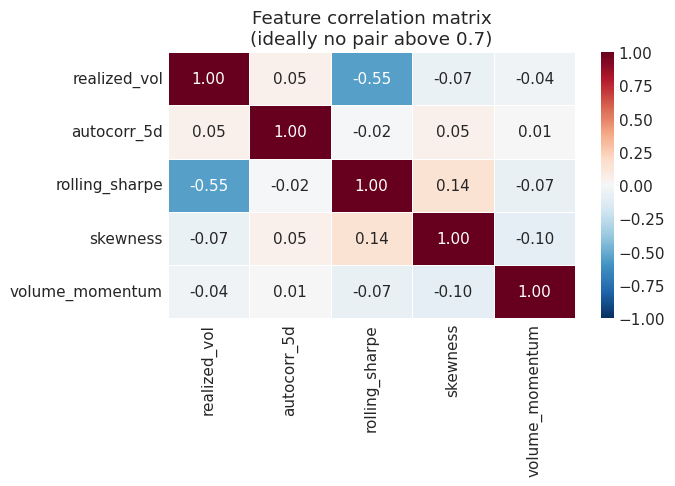


Highly correlated pairs (|r| > 0.7):


In [6]:
import seaborn as sns

corr = features.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5)
ax.set_title("Feature correlation matrix\n(ideally no pair above 0.7)")
plt.tight_layout()
plt.savefig('../logs/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag any pairs that are too correlated
print("\nHighly correlated pairs (|r| > 0.7):")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {corr.columns[i]} vs {corr.columns[j]}: r={r:.3f}  ← consider dropping one")